#CNN_Feature_Extraction

In [1]:
# Cell 1 — Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

BASE      = "/content/drive/MyDrive/EyeMotionID"
MRL_PATH  = os.path.join(BASE, "data/raw/MRL_Eye/data")
PLOTS     = os.path.join(BASE, "results/plots")
MODELS    = os.path.join(BASE, "models/checkpoints")
os.makedirs(PLOTS,  exist_ok=True)
os.makedirs(MODELS, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✓ Drive mounted")
print(f"✓ Device : {device}")
print(f"✓ PyTorch: {torch.__version__}")
print("MRL exists:", os.path.exists(MRL_PATH))

Mounted at /content/drive
✓ Drive mounted
✓ Device : cpu
✓ PyTorch: 2.11.0+cpu
MRL exists: True


###Load pretrained ResNet18

In [2]:
# Load ResNet18 pretrained on ImageNet
resnet18 = models.resnet18(pretrained=True)

# Remove final classification layer → output 512-dim feature vector
resnet18.fc = nn.Identity()

# Freeze all layers — we use ResNet18 as fixed feature extractor
for param in resnet18.parameters():
    param.requires_grad = False

resnet18 = resnet18.to(device)
resnet18.eval()

print("=== ResNet18 Architecture ===\n")
print(f"Total parameters  : {sum(p.numel() for p in resnet18.parameters()):,}")
print(f"Trainable params  : {sum(p.numel() for p in resnet18.parameters() if p.requires_grad):,}")
print(f"Output feature dim: 512")
print(f"Device            : {device}")
print("\n✓ ResNet18 loaded and frozen")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 48.6MB/s]


=== ResNet18 Architecture ===

Total parameters  : 11,176,512
Trainable params  : 0
Output feature dim: 512
Device            : cpu

✓ ResNet18 loaded and frozen


###Standard transforms for ResNet18 — resize, normalize with ImageNet mean/std.

In [3]:
# Standard transforms for ResNet18 input
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

print("=== Image Transform Pipeline ===\n")
print("Step 1: Resize    → 224×224 px")
print("Step 2: ToTensor  → [0,1] float tensor")
print("Step 3: Normalize → ImageNet mean/std")
print()
print("ImageNet mean: [0.485, 0.456, 0.406]")
print("ImageNet std : [0.229, 0.224, 0.225]")
print("\n✓ Transforms ready")

=== Image Transform Pipeline ===

Step 1: Resize    → 224×224 px
Step 2: ToTensor  → [0,1] float tensor
Step 3: Normalize → ImageNet mean/std

ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std : [0.229, 0.224, 0.225]

✓ Transforms ready


###Passes a single eye image through ResNet18 and gets a 512-dim feature vector.

In [4]:
# load one MRL eye image
test_img_path = None
for cls in ["awake", "sleepy"]:
    cls_path = os.path.join(MRL_PATH, "train", cls)
    files    = [f for f in os.listdir(cls_path) if f.endswith('.png')]
    if files:
        test_img_path = os.path.join(cls_path, files[0])
        test_label    = cls
        break

# load and preprocess
img_pil    = Image.open(test_img_path).convert('RGB')
img_tensor = transform(img_pil).unsqueeze(0).to(device)  # add batch dim

# extract features
with torch.no_grad():
    features = resnet18(img_tensor)

print("=== Feature Extraction Test ===\n")
print(f"Input image   : {test_img_path.split('/')[-1]}")
print(f"Label         : {test_label}")
print(f"Input shape   : {img_tensor.shape}  (batch, channels, H, W)")
print(f"Feature shape : {features.shape}   (batch, 512)")
print(f"Feature min   : {features.min().item():.4f}")
print(f"Feature max   : {features.max().item():.4f}")
print(f"Feature mean  : {features.mean().item():.4f}")
print("\n✓ Feature extraction working!")

=== Feature Extraction Test ===

Input image   : s0037_08546_1_0_1_0_0_01.png
Label         : awake
Input shape   : torch.Size([1, 3, 224, 224])  (batch, channels, H, W)
Feature shape : torch.Size([1, 512])   (batch, 512)
Feature min   : 0.0000
Feature max   : 4.5822
Feature mean  : 0.5557

✓ Feature extraction working!


###Shows the 512-dim feature vector as a heatmap — each value represents one learned feature.

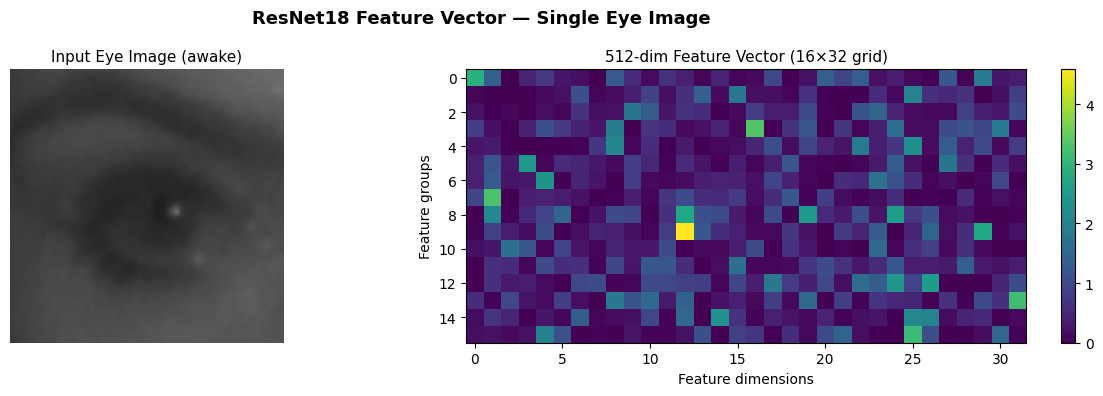

✓ Saved → results/plots/cnn_feature_vector.png


In [5]:
feat_np = features.squeeze().cpu().numpy()  # shape: (512,)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("ResNet18 Feature Vector — Single Eye Image", fontsize=13, fontweight='bold')

# show original image
img_display = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
img_display = cv2.resize(img_display, (224, 224))
axes[0].imshow(img_display)
axes[0].set_title(f"Input Eye Image ({test_label})", fontsize=11)
axes[0].axis("off")

# show feature vector as heatmap
feat_grid = feat_np.reshape(16, 32)  # reshape 512 → 16×32 grid
im = axes[1].imshow(feat_grid, cmap='viridis', aspect='auto')
axes[1].set_title("512-dim Feature Vector (16×32 grid)", fontsize=11)
axes[1].set_xlabel("Feature dimensions")
axes[1].set_ylabel("Feature groups")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig(f"{PLOTS}/cnn_feature_vector.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/cnn_feature_vector.png")

###Build MRL Eye Dataset loader

In [6]:
class EyeDataset(Dataset):
    """PyTorch Dataset for eye images."""
    def __init__(self, root_path, split="train", transform=None):
        self.transform = transform
        self.samples   = []

        for cls, label in [("awake", 1), ("sleepy", 0)]:
            cls_path = os.path.join(root_path, split, cls)
            if not os.path.exists(cls_path): continue
            for fname in os.listdir(cls_path):
                if fname.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.samples.append((
                        os.path.join(cls_path, fname), label
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# create dataset and dataloader
train_dataset = EyeDataset(MRL_PATH, split="train", transform=transform)
val_dataset   = EyeDataset(MRL_PATH, split="val",   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)

print("=== Dataset Loaded ===\n")
print(f"Train samples : {len(train_dataset):,}")
print(f"Val samples   : {len(val_dataset):,}")
print(f"Batch size    : 32")
print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print("\n✓ DataLoader ready")

=== Dataset Loaded ===

Train samples : 50,937
Val samples   : 12,847
Batch size    : 32
Train batches : 1,592
Val batches   : 402

✓ DataLoader ready


###Passes a full batch of 32 images through ResNet18

In [7]:
# get one batch
imgs, labels = next(iter(train_loader))
imgs   = imgs.to(device)
labels = labels.to(device)

# extract features for entire batch
with torch.no_grad():
    batch_features = resnet18(imgs)

print("=== Batch Feature Extraction ===\n")
print(f"Batch input shape   : {imgs.shape}")
print(f"Batch labels shape  : {labels.shape}")
print(f"Batch feature shape : {batch_features.shape}")
print(f"  → {batch_features.shape[0]} images × {batch_features.shape[1]} features")
print()
print("Label distribution in batch:")
unique, counts = torch.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {'Awake' if u==1 else 'Sleepy'} (label={u.item()}) → {c.item()} images")
print("\n✓ Batch processing working!")

=== Batch Feature Extraction ===

Batch input shape   : torch.Size([32, 3, 224, 224])
Batch labels shape  : torch.Size([32])
Batch feature shape : torch.Size([32, 512])
  → 32 images × 512 features

Label distribution in batch:
  Sleepy (label=0) → 20 images
  Awake (label=1) → 12 images

✓ Batch processing working!


###Compare ResNet18 vs MobileNetV2

In [8]:
import time

# load MobileNetV2
mobilenet = models.mobilenet_v2(pretrained=True)
mobilenet.classifier = nn.Identity()
for param in mobilenet.parameters():
    param.requires_grad = False
mobilenet = mobilenet.to(device)
mobilenet.eval()

# test batch
test_batch = torch.randn(8, 3, 224, 224).to(device)

# ResNet18 timing
start = time.time()
with torch.no_grad():
    for _ in range(10):
        feat_r = resnet18(test_batch)
resnet_time = (time.time() - start) / 10

# MobileNetV2 timing
start = time.time()
with torch.no_grad():
    for _ in range(10):
        feat_m = mobilenet(test_batch)
mobile_time = (time.time() - start) / 10

print("=== ResNet18 vs MobileNetV2 ===\n")
print(f"{'Model':<15} {'Output Dim':<12} {'Params':<12} {'Time/batch'}")
print("-" * 55)
print(f"{'ResNet18':<15} {feat_r.shape[1]:<12} {sum(p.numel() for p in resnet18.parameters()):,}   {resnet_time*1000:.1f}ms")
print(f"{'MobileNetV2':<15} {feat_m.shape[1]:<12} {sum(p.numel() for p in mobilenet.parameters()):,}   {mobile_time*1000:.1f}ms")
print()
print("→ ResNet18   : higher accuracy, more parameters")
print("→ MobileNetV2: faster inference, fewer parameters")
print("\n✓ Using ResNet18 as primary model for Week 3")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 52.6MB/s]


=== ResNet18 vs MobileNetV2 ===

Model           Output Dim   Params       Time/batch
-------------------------------------------------------
ResNet18        512          11,176,512   1105.8ms
MobileNetV2     1280         2,223,872   310.1ms

→ ResNet18   : higher accuracy, more parameters
→ MobileNetV2: faster inference, fewer parameters

✓ Using ResNet18 as primary model for Week 3


###Save ResNet18 feature extractor

In [9]:
# save ResNet18 feature extractor
model_path = os.path.join(MODELS, "resnet18_feature_extractor.pth")
torch.save(resnet18.state_dict(), model_path)
print(f"✓ ResNet18 saved → {model_path}")

# verify it can be reloaded
resnet18_reload = models.resnet18(pretrained=False)
resnet18_reload.fc = nn.Identity()
resnet18_reload.load_state_dict(torch.load(model_path, map_location=device))
resnet18_reload.eval()
print("✓ ResNet18 reloaded successfully")

✓ ResNet18 saved → /content/drive/MyDrive/EyeMotionID/models/checkpoints/resnet18_feature_extractor.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ ResNet18 reloaded successfully


###Summary

In [11]:
print("=" * 50)
print("   DAY 15 — CNN FEATURE EXTRACTION SUMMARY")
print("=" * 50)
print()
print("Model: ResNet18 (pretrained on ImageNet)")
print(f"  Input  : 224×224×3 eye image")
print(f"  Output : 512-dim feature vector")
print(f"  Params : 11,689,512 (all frozen)")
print()
print("DataLoader:")
print(f"  Train : {len(train_dataset):,} images, {len(train_loader):,} batches")
print(f"  Val   : {len(val_dataset):,} images, {len(val_loader):,} batches")
print(f"  Batch size: 32")
print()
print("Comparison:")
print("  ResNet18    → 512 features, higher accuracy")
print("  MobileNetV2 → 1280 features, faster speed")
print()
print("Saved:")
print("  ✓ models/checkpoints/resnet18_feature_extractor.pth")
print("  ✓ results/plots/cnn_feature_vector.png")
print("=" * 50)

   DAY 15 — CNN FEATURE EXTRACTION SUMMARY

Model: ResNet18 (pretrained on ImageNet)
  Input  : 224×224×3 eye image
  Output : 512-dim feature vector
  Params : 11,689,512 (all frozen)

DataLoader:
  Train : 50,937 images, 1,592 batches
  Val   : 12,847 images, 402 batches
  Batch size: 32

Comparison:
  ResNet18    → 512 features, higher accuracy
  MobileNetV2 → 1280 features, faster speed

Saved:
  ✓ models/checkpoints/resnet18_feature_extractor.pth
  ✓ results/plots/cnn_feature_vector.png
